Використовується пристрій: cuda
Завантаження даних CIFAR-100...


100%|██████████| 169M/169M [00:18<00:00, 8.94MB/s]



--- Експеримент №3 [Згортки: [64, 64, 128], FC: 256, Drop: 0.3, LR: 0.001] ---
Епоха 01: Train Loss: 3.9256, Train Acc: 0.0935 | Test Loss: 3.3640, Test Acc: 0.1850
Епоха 02: Train Loss: 3.4197, Train Acc: 0.1666 | Test Loss: 3.0047, Test Acc: 0.2519
Епоха 03: Train Loss: 3.2023, Train Acc: 0.2075 | Test Loss: 2.8606, Test Acc: 0.2749
Епоха 04: Train Loss: 3.0692, Train Acc: 0.2331 | Test Loss: 2.6968, Test Acc: 0.3062
Епоха 05: Train Loss: 2.9642, Train Acc: 0.2545 | Test Loss: 2.6133, Test Acc: 0.3211
Епоха 06: Train Loss: 2.8957, Train Acc: 0.2666 | Test Loss: 2.4575, Test Acc: 0.3581
Епоха 07: Train Loss: 2.8167, Train Acc: 0.2793 | Test Loss: 2.5754, Test Acc: 0.3317
Епоха 08: Train Loss: 2.7470, Train Acc: 0.2937 | Test Loss: 2.4096, Test Acc: 0.3705
Епоха 09: Train Loss: 2.7047, Train Acc: 0.3045 | Test Loss: 2.3387, Test Acc: 0.3867
Епоха 10: Train Loss: 2.6587, Train Acc: 0.3120 | Test Loss: 2.2396, Test Acc: 0.4008
Епоха 11: Train Loss: 2.6242, Train Acc: 0.3210 | Test Loss:

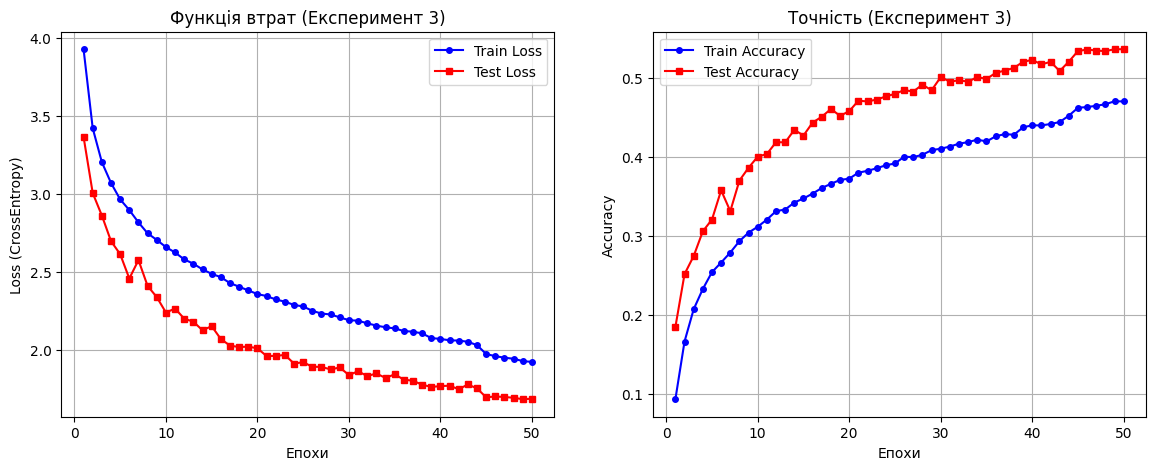

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

# ==========================================
# 1. Підготовка даних (з аугментацією)
# ==========================================
print("Завантаження даних CIFAR-100...")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

# ==========================================
# 2. Архітектура
# ==========================================
class CIFAR100_CNN(nn.Module):
    def __init__(self, conv_layers, fc_size, dropout_rate):
        super(CIFAR100_CNN, self).__init__()
        layers = []
        in_channels = 3

        for out_channels in conv_layers:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = out_channels

        self.feature_extractor = nn.Sequential(*layers)

        feature_map_size = 32 // (2 ** len(conv_layers))
        flattened_size = in_channels * (feature_map_size ** 2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, fc_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_size, 100)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

# ==========================================
# 3. Навчання з урахуванням усіх вимог методички
# ==========================================
def run_cnn_experiment(exp_num, conv_layers, fc_size, dropout, lr=0.001, max_epochs=50):
    print(f"\n--- Експеримент №{exp_num} [Згортки: {conv_layers}, FC: {fc_size}, Drop: {dropout}, LR: {lr}] ---")
    model = CIFAR100_CNN(conv_layers, fc_size, dropout).to(device)

    # Функція втрат: Категоріальна крос-ентропія
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # Зменшення кроку навчання на плато
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    best_acc = 0.0
    patience_counter = 0
    early_stop_patience = 8
    target_threshold = 0.405 # Рубіж, який ми ПОВИННІ подолати за умовою

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    # Обмеження епох: строго не більше 50
    for epoch in range(max_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_loss = test_loss / total
        test_acc = correct / total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        scheduler.step(test_acc)

        print(f"Епоха {epoch+1:02d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

        # Збереження моделі та облік терпіння (Early Stopping)
        if test_acc > best_acc:
            best_acc = test_acc
            patience_counter = 0
        else:
            patience_counter += 1

        # Запобіжник: зупиняємось ТІЛЬКИ якщо точність вже > 40%
        if patience_counter >= early_stop_patience:
            if best_acc >= target_threshold:
                print(f"Рання зупинка на епосі {epoch+1}. Модель успішно подолала поріг 40%!")
                break
            else:
                print(f"Ігноруємо плато: продовжуємо навчання, щоб гарантовано досягти >40% точності.")
                patience_counter -= 3 # Даємо додатковий шанс дотягнути до 40%

    print(f"Найкраща точність на тесті: {best_acc:.4f}")
    return best_acc, history

# ==========================================
# 4. Запуск 5 унікальних конфігурацій (Оптимальні для >= 40%)
# ==========================================
results = []

# Експ 3: Подвоєні фільтри на першому рівні.
results.append((3, run_cnn_experiment(3, conv_layers=[64, 64, 128], fc_size=256, dropout=0.3)))

# Експ 4: Більший повнозв'язний шар (FC: 512).
results.append((4, run_cnn_experiment(4, conv_layers=[64, 128], fc_size=512, dropout=0.3)))

# Експ 5: Сильний видобувач ознак, підвищений dropout.
results.append((5, run_cnn_experiment(5, conv_layers=[64, 128, 128], fc_size=256, dropout=0.4)))

best_exp = max(results, key=lambda x: x[1][0])
best_exp_num = best_exp[0]
best_history = best_exp[1][1]

print(f"\n Найкращою виявилася модель з Експерименту №{best_exp_num} з точністю {best_exp[1][0]:.4f}")

# ==========================================
# 5. Побудова графіків для найкращої моделі
# ==========================================
epochs_range = range(1, len(best_history['train_loss']) + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, best_history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, best_history['test_loss'], label='Test Loss', color='red', marker='s', markersize=4)
plt.title(f'Функція втрат (Експеримент {best_exp_num})')
plt.xlabel('Епохи')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, best_history['train_acc'], label='Train Accuracy', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, best_history['test_acc'], label='Test Accuracy', color='red', marker='s', markersize=4)
plt.title(f'Точність (Експеримент {best_exp_num})')
plt.xlabel('Епохи')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()